In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

In [2]:
df_train = pd.read_csv('../data/processed/2017/2017_train_scaled.csv')
df_test = pd.read_csv('../data/processed/2017/2017_test_scaled.csv')

In [3]:
X_train_benign = df_train[df_train["Label"] == 0].drop(columns=["Label"])
X_test = df_test.drop(columns=["Label"])
y_train = df_train['Label']
y_test = df_test['Label']

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32,latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64,input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [5]:
input_dim = X_train_benign.shape[1]
model = Autoencoder(input_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

X_tensor = torch.tensor(X_train_benign.values, dtype=torch.float32)
loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=True)

losses = []

for epoch in range(30):
    model.train()
    total_loss = 0
    for (batch,) in loader:
        optimizer.zero_grad()
        loss = criterion(model(batch), batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    epoch_loss = total_loss / len(loader)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.6f}")

torch.save(model.state_dict(), "../models/baseline_model_2017.pth")

Epoch 1 | Loss: 0.638393
Epoch 2 | Loss: 0.357660
Epoch 3 | Loss: 0.328146
Epoch 4 | Loss: 0.311084
Epoch 5 | Loss: 0.300029
Epoch 6 | Loss: 0.291448
Epoch 7 | Loss: 0.284119
Epoch 8 | Loss: 0.278622
Epoch 9 | Loss: 0.273660
Epoch 10 | Loss: 0.269845
Epoch 11 | Loss: 0.266321
Epoch 12 | Loss: 0.263536
Epoch 13 | Loss: 0.260801
Epoch 14 | Loss: 0.258555
Epoch 15 | Loss: 0.256084
Epoch 16 | Loss: 0.255264
Epoch 17 | Loss: 0.252568
Epoch 18 | Loss: 0.251710
Epoch 19 | Loss: 0.250195
Epoch 20 | Loss: 0.248169
Epoch 21 | Loss: 0.246664
Epoch 22 | Loss: 0.245236
Epoch 23 | Loss: 0.244537
Epoch 24 | Loss: 0.243233
Epoch 25 | Loss: 0.242362
Epoch 26 | Loss: 0.241233
Epoch 27 | Loss: 0.240225
Epoch 28 | Loss: 0.238976
Epoch 29 | Loss: 0.238309
Epoch 30 | Loss: 0.237253


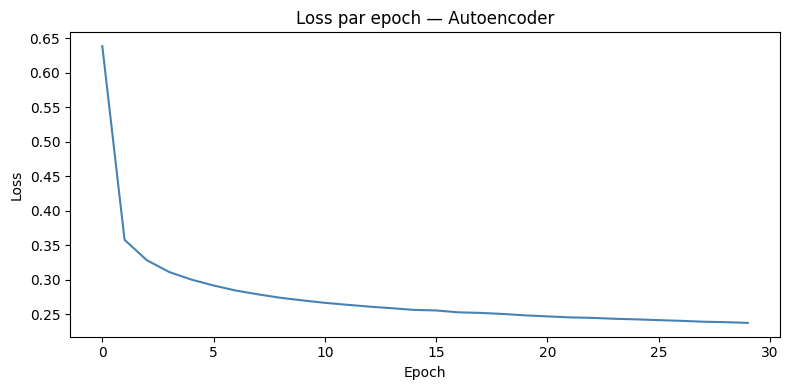

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color="steelblue")
plt.title("Loss par epoch — Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [11]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    reconstructed = model(X_test_tensor)
    errors = ((X_test_tensor - reconstructed) ** 2).mean(dim=1).numpy()

benign_errors = errors[y_test.values == 0]

threshold = np.percentile(benign_errors, 90)

print(f"Seuil : {threshold:.6f}")
y_pred = (errors > threshold).astype(int)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC : {roc_auc_score(y_test, errors):.4f}")

Seuil : 0.288081
              precision    recall  f1-score   support

           0       0.94      0.90      0.92    454265
           1       0.66      0.78      0.71    111311

    accuracy                           0.88    565576
   macro avg       0.80      0.84      0.82    565576
weighted avg       0.89      0.88      0.88    565576

ROC-AUC : 0.9143


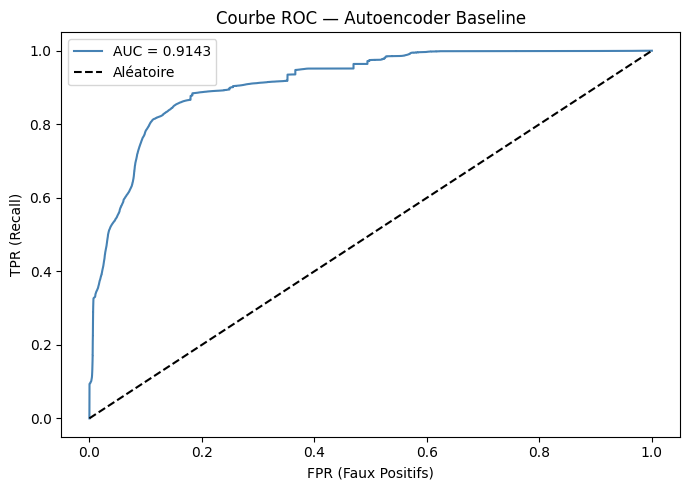

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, errors)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, errors):.4f}", color="steelblue")
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire")
plt.xlabel("FPR (Faux Positifs)")
plt.ylabel("TPR (Recall)")
plt.title("Courbe ROC — Autoencoder Baseline")
plt.legend()
plt.tight_layout()
plt.show()

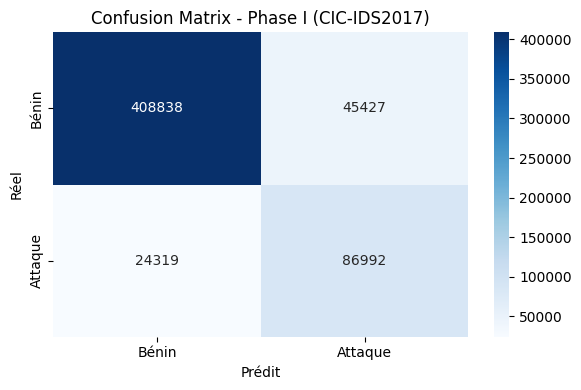

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bénin', 'Attaque'],
            yticklabels=['Bénin', 'Attaque'])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Confusion Matrix - Phase I (CIC-IDS2017)")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_phase1.png", dpi=150)
plt.show()